========================================================================================================================

**Submitted By:**<br>
**Name –** Ayushman Behera<br>
**Registration No. -** 12301257<br>
**Roll No. -** 50<br>
**Section -** 223UP<br>
<br>
**Submitted To:**<br>
Karan Kumar Das

========================================================================================================================

<h2 align="center">LoanGuard: Credit Risk Assessment & Customer Segmentation</h2>


### Machine Learning Mini Project

**Models Implemented:**
1. Multiple Linear Regression (Loan Amount Prediction)
2. Logistic Regression (Default Risk Classification)
3. K-Means Clustering (Customer Segmentation)

## Cell 1 — Import Libraries


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, silhouette_score
)
from sklearn.decomposition import PCA


## Cell 2 — Load Dataset


In [62]:
df = pd.read_csv('loan_data.csv')
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Cell 3 — Dataset Information


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [64]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## Cell 4 — Check Missing Values


In [65]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})


## Cell 5 — Handle Missing Values (if any)


In [66]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


## Cell 6 — Encode Categorical Variables


In [67]:
df_model = df.copy()
le = LabelEncoder()
categorical_columns = ['person_gender', 'person_education', 'person_home_ownership', 
                       'loan_intent', 'previous_loan_defaults_on_file']
for col in categorical_columns:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col])
df_model.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


## Cell 7 — Exploratory Data Analysis (EDA)
### Target Variable Distribution


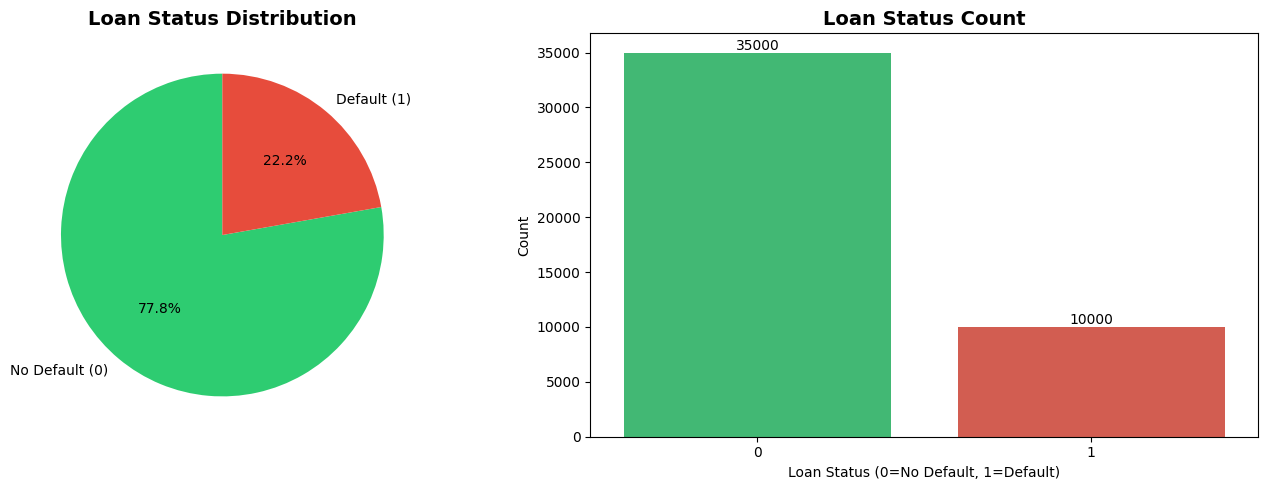

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loan_counts = df['loan_status'].value_counts()

axes[0].pie(
    loan_counts,
    labels=['No Default (0)', 'Default (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#e74c3c']
)

axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')

sns.countplot(
    x='loan_status',
    data=df,
    hue='loan_status',
    palette=['#2ecc71', '#e74c3c'],
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Loan Status Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loan Status (0=No Default, 1=Default)')
axes[1].set_ylabel('Count')

for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

## Cell 8 — Distribution of Numerical Features


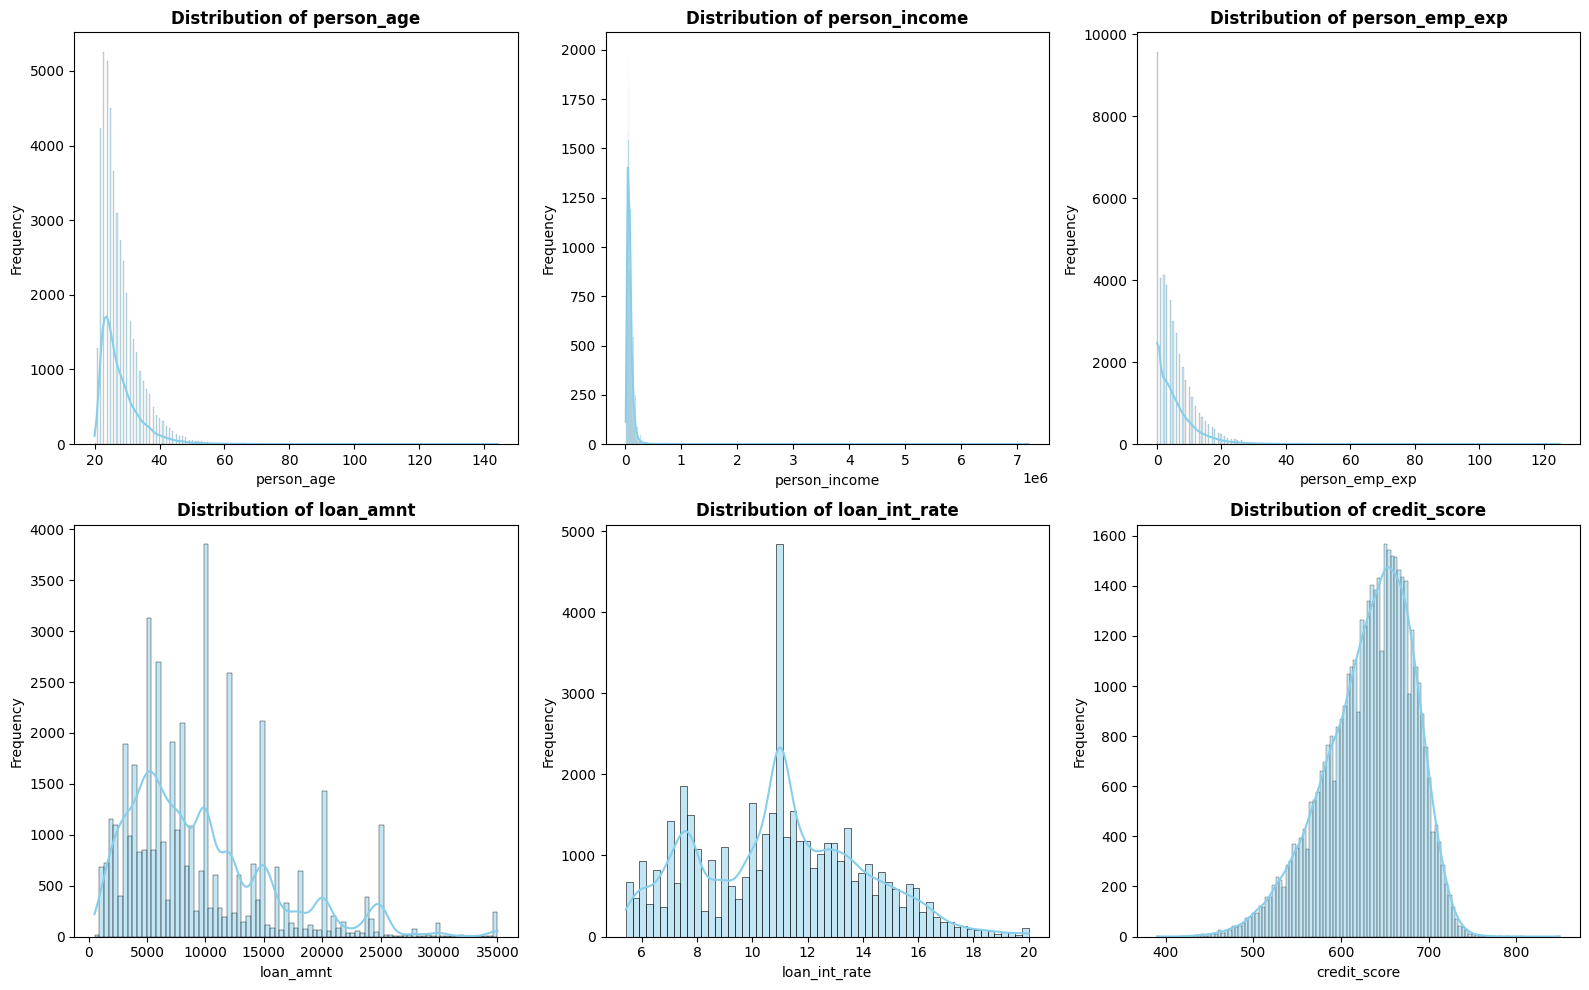

In [69]:
numerical_features = ['person_age', 'person_income', 'person_emp_exp', 
                      'loan_amnt', 'loan_int_rate', 'credit_score']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


## Cell 9 — Boxplots - Features vs Loan Status


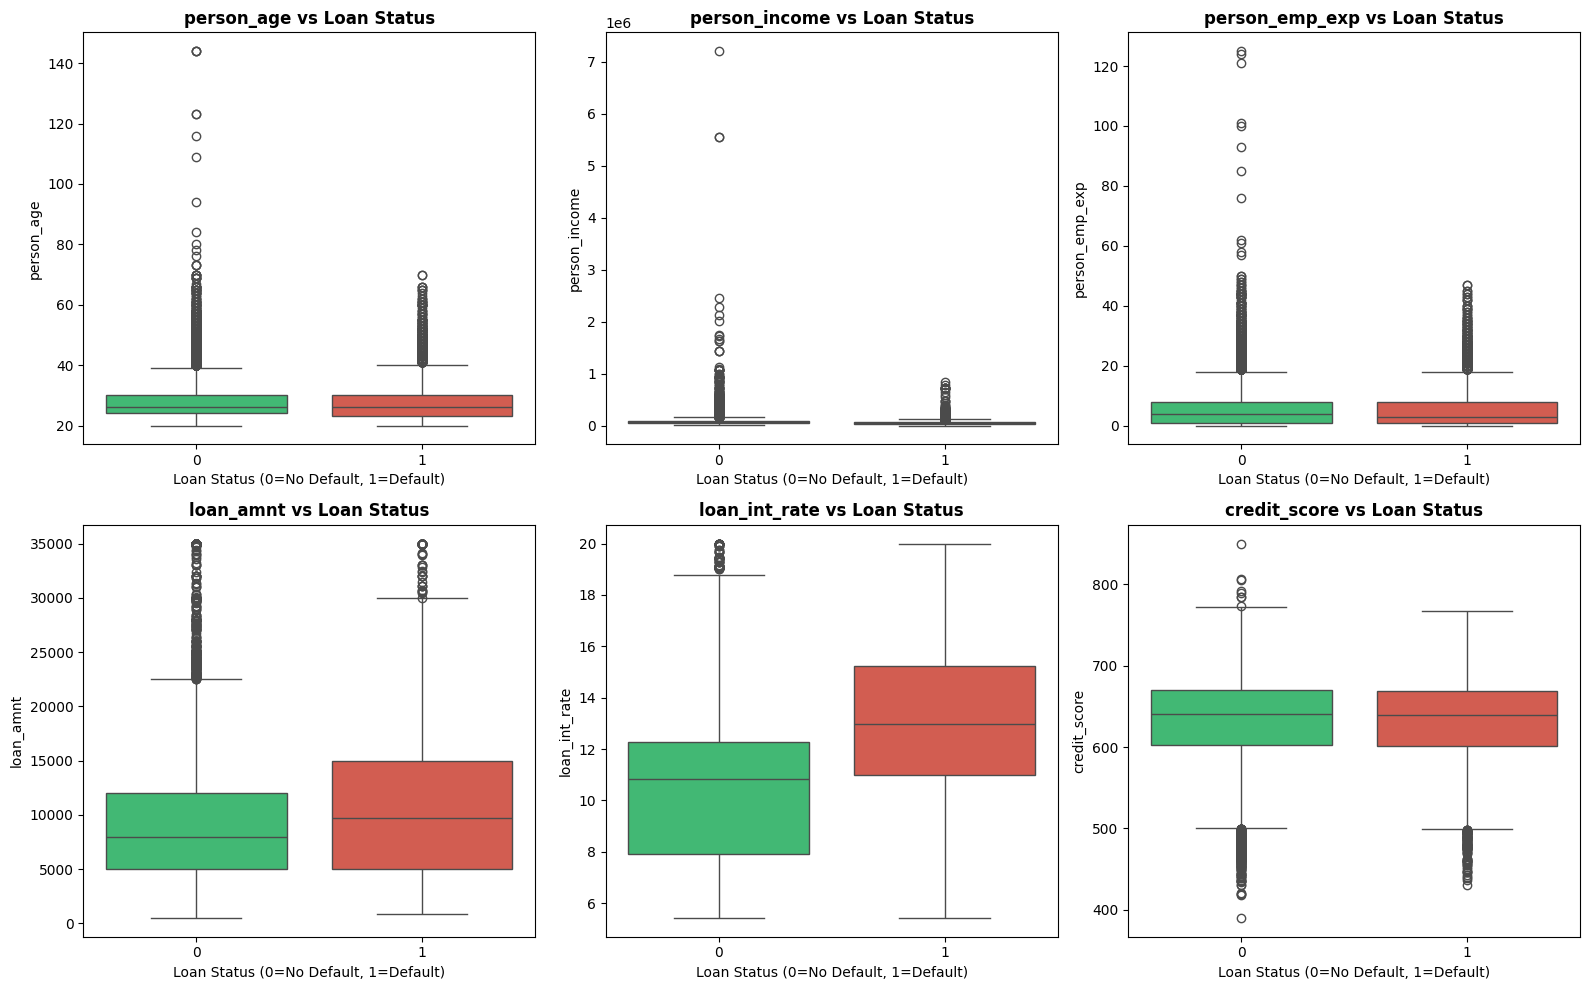

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.boxplot(
        x='loan_status',
        y=col,
        data=df,
        hue='loan_status',
        palette=['#2ecc71', '#e74c3c'],
        legend=False,
        ax=axes[idx]
    )
    
    axes[idx].set_title(f'{col} vs Loan Status', fontweight='bold')
    axes[idx].set_xlabel('Loan Status (0=No Default, 1=Default)')

plt.tight_layout()
plt.show()

## Cell 10 — Correlation Heatmap


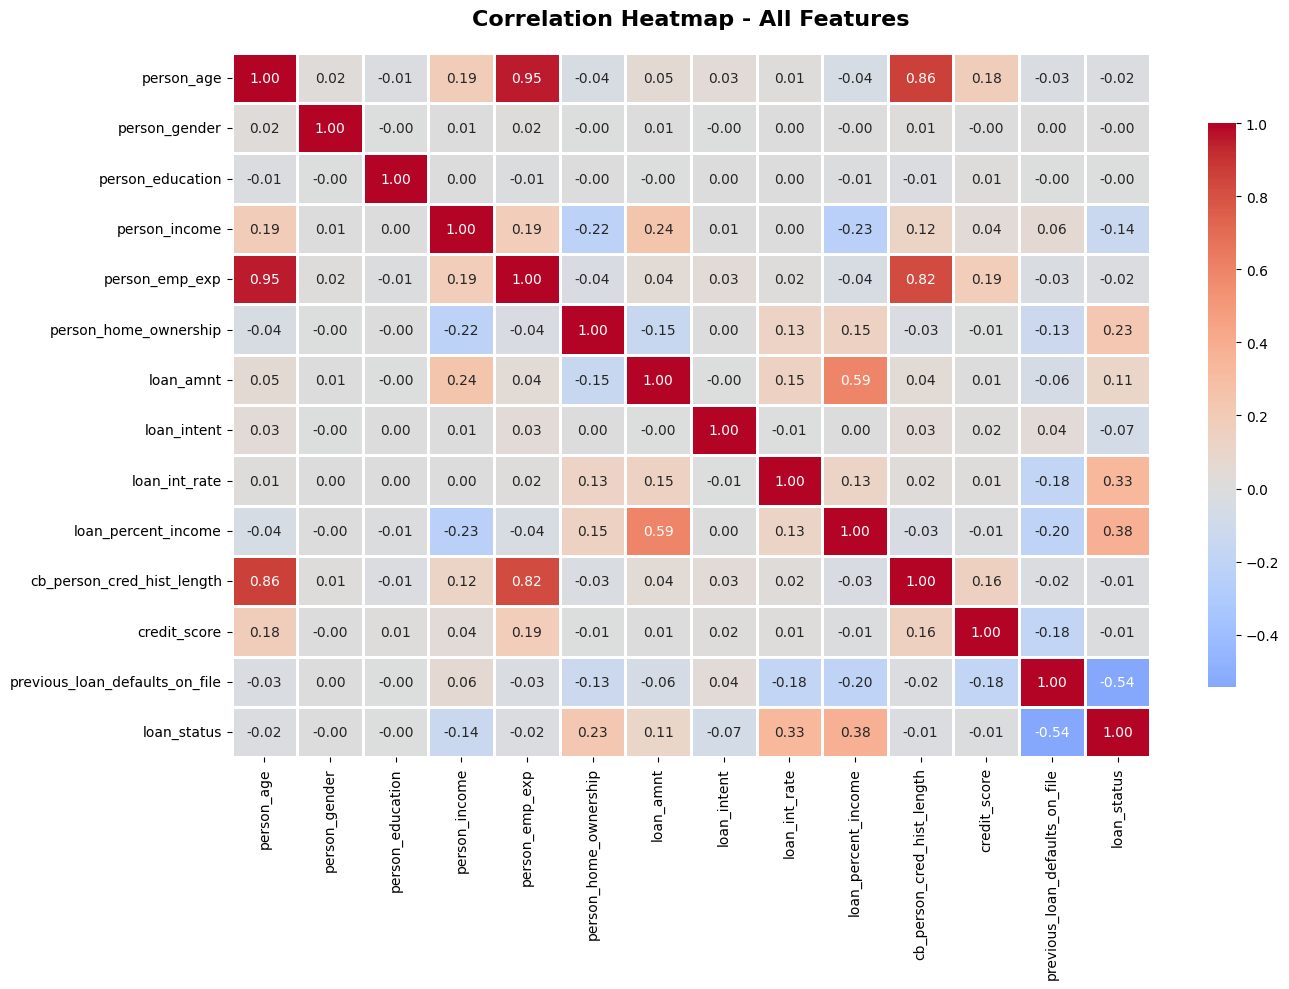

In [71]:
plt.figure(figsize=(14, 10))
correlation = df_model.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## Cell 11 — Scatter Plots


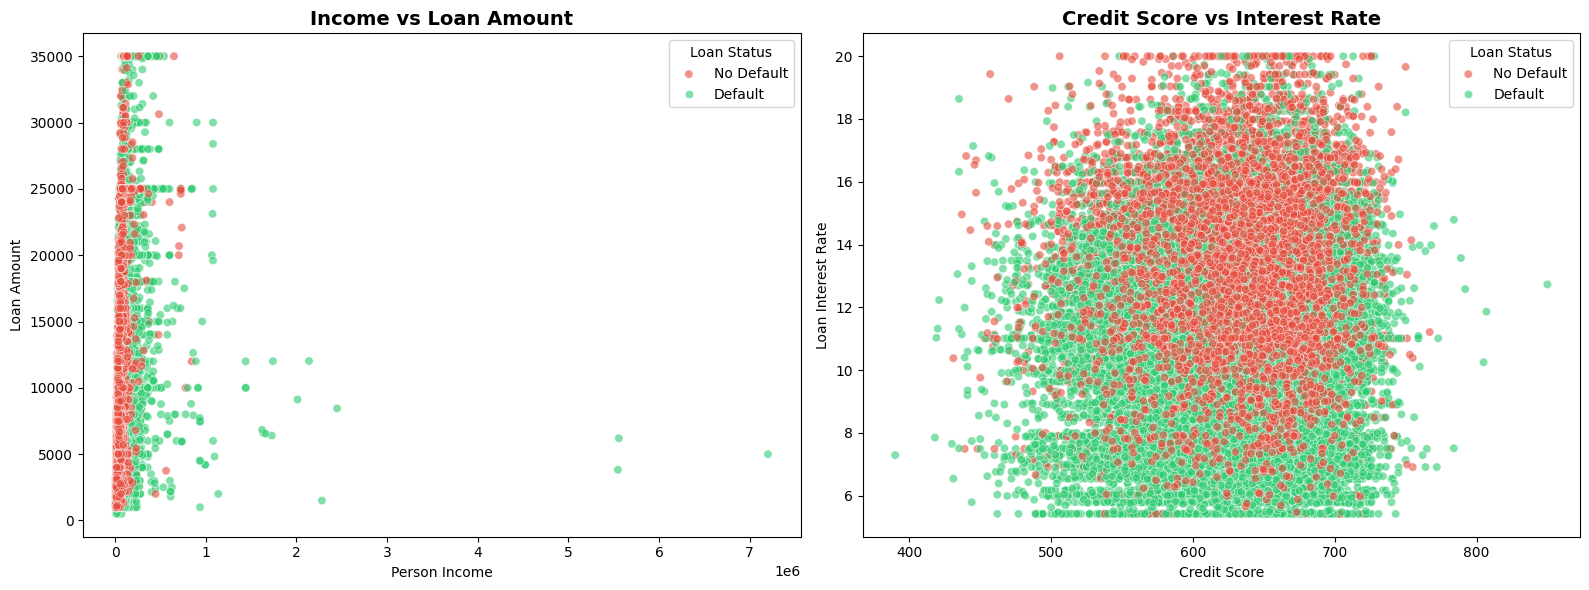

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', 
                data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0], alpha=0.6)
axes[0].set_title('Income vs Loan Amount', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Person Income')
axes[0].set_ylabel('Loan Amount')
axes[0].legend(title='Loan Status', labels=['No Default', 'Default'])
sns.scatterplot(x='credit_score', y='loan_int_rate', hue='loan_status', 
                data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1], alpha=0.6)
axes[1].set_title('Credit Score vs Interest Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Loan Interest Rate')
axes[1].legend(title='Loan Status', labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()


# PART 1: Multiple Linear Regression
## Predicting Loan Amount


## Cell 12 — Prepare Data for Linear Regression


In [73]:
features_linear = ['person_income', 'credit_score', 'person_emp_exp', 
                   'loan_int_rate', 'loan_percent_income']
X_linear = df_model[features_linear]
y_linear = df_model['loan_amnt']


## Cell 13 — Train-Test Split for Linear Regression


In [74]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)


## Cell 14 — Train Linear Regression Model


In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
for feature, coef in zip(features_linear, lr_model.coef_):
    print(f"Feature: {feature:25} Coefficient: {coef:.4f}")
print(f"Intercept: {lr_model.intercept_:.4f}")


Feature: person_income             Coefficient: 0.0281
Feature: credit_score              Coefficient: 0.5188
Feature: person_emp_exp            Coefficient: -6.0285
Feature: loan_int_rate             Coefficient: 131.2885
Feature: loan_percent_income       Coefficient: 48451.9189
Intercept: -1194.2062


## Cell 15 — Make Predictions & Evaluate


In [76]:
y_pred_lr = lr_model.predict(X_test_lr)
mae = mean_absolute_error(y_test_lr, y_pred_lr)
mse = mean_squared_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_lr, y_pred_lr)


## Cell 16 — Visualize Linear Regression Results


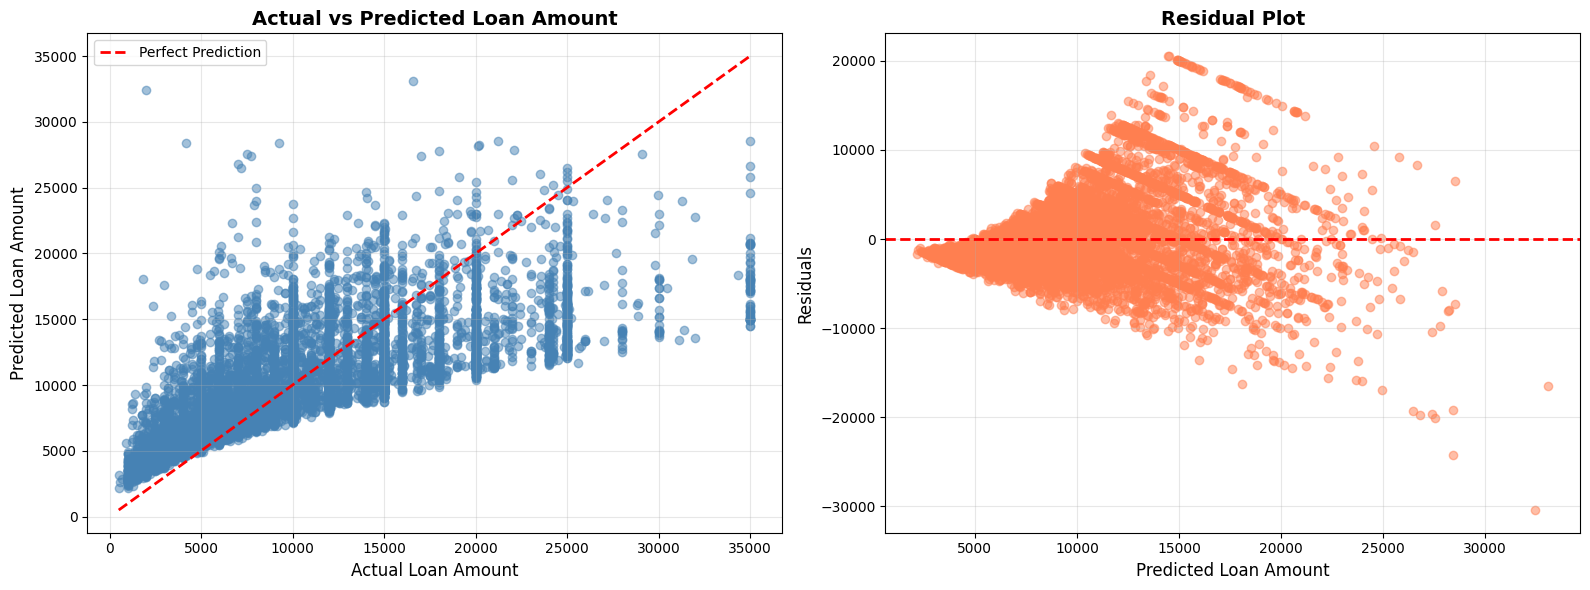

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_test_lr, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([y_test_lr.min(), y_test_lr.max()], 
             [y_test_lr.min(), y_test_lr.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Loan Amount', fontsize=12)
axes[0].set_ylabel('Predicted Loan Amount', fontsize=12)
axes[0].set_title('Actual vs Predicted Loan Amount', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
residuals = y_test_lr - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Loan Amount', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# PART 2: Logistic Regression
## Predicting Loan Default Risk


## Cell 17 — Prepare Data for Logistic Regression


In [78]:
features_logistic = ['person_income', 'loan_amnt', 'credit_score', 
                     'loan_int_rate', 'person_emp_exp', 'loan_percent_income']
X_logistic = df_model[features_logistic]
y_logistic = df_model['loan_status']


## Cell 18 — Train-Test Split for Logistic Regression


In [79]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_logistic, y_logistic, test_size=0.2, random_state=42, stratify=y_logistic
)


## Cell 19 — Train Logistic Regression Model


In [80]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log, y_train_log)
for feature, coef in zip(features_logistic, log_model.coef_[0]):
    print(f"Feature: {feature:25} Coefficient: {coef:.4f}")
print(f"Intercept: {log_model.intercept_[0]:.4f}")


Feature: person_income             Coefficient: -0.0000
Feature: loan_amnt                 Coefficient: -0.0001
Feature: credit_score              Coefficient: -0.0001
Feature: loan_int_rate             Coefficient: 0.3315
Feature: person_emp_exp            Coefficient: 0.0014
Feature: loan_percent_income       Coefficient: 14.3708
Intercept: -6.3532


## Cell 20 — Make Predictions & Evaluate


In [81]:
y_pred_log = log_model.predict(X_test_log)
y_pred_proba = log_model.predict_proba(X_test_log)[:, 1]
acc = accuracy_score(y_test_log, y_pred_log)
roc_auc = roc_auc_score(y_test_log, y_pred_proba)
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(classification_report(y_test_log, y_pred_log,
                            target_names=['No Default (0)', 'Default (1)']))


Accuracy: 0.8261
ROC AUC: 0.8369
                precision    recall  f1-score   support

No Default (0)       0.85      0.95      0.89      7000
   Default (1)       0.69      0.39      0.50      2000

      accuracy                           0.83      9000
     macro avg       0.77      0.67      0.70      9000
  weighted avg       0.81      0.83      0.81      9000



## Cell 21 — Confusion Matrix


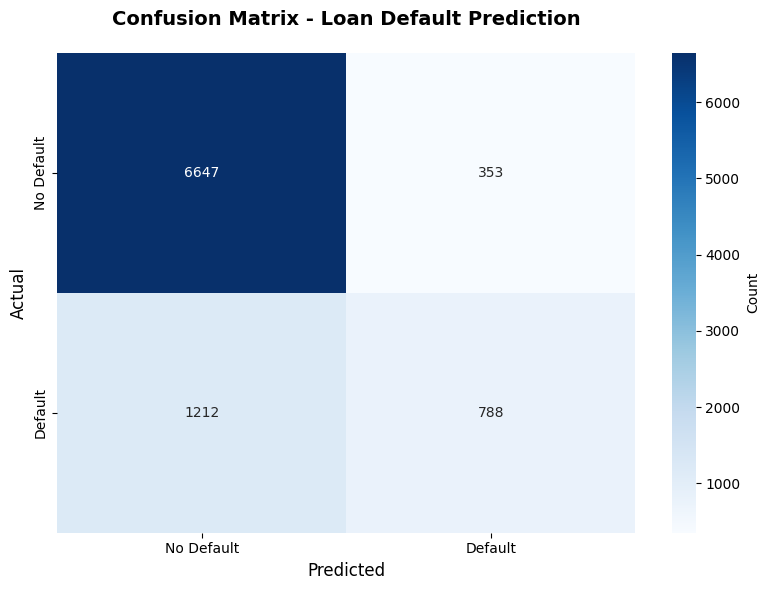

In [82]:
cm = confusion_matrix(y_test_log, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Loan Default Prediction', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()
tn, fp, fn, tp = cm.ravel()


## Cell 22 — ROC Curve


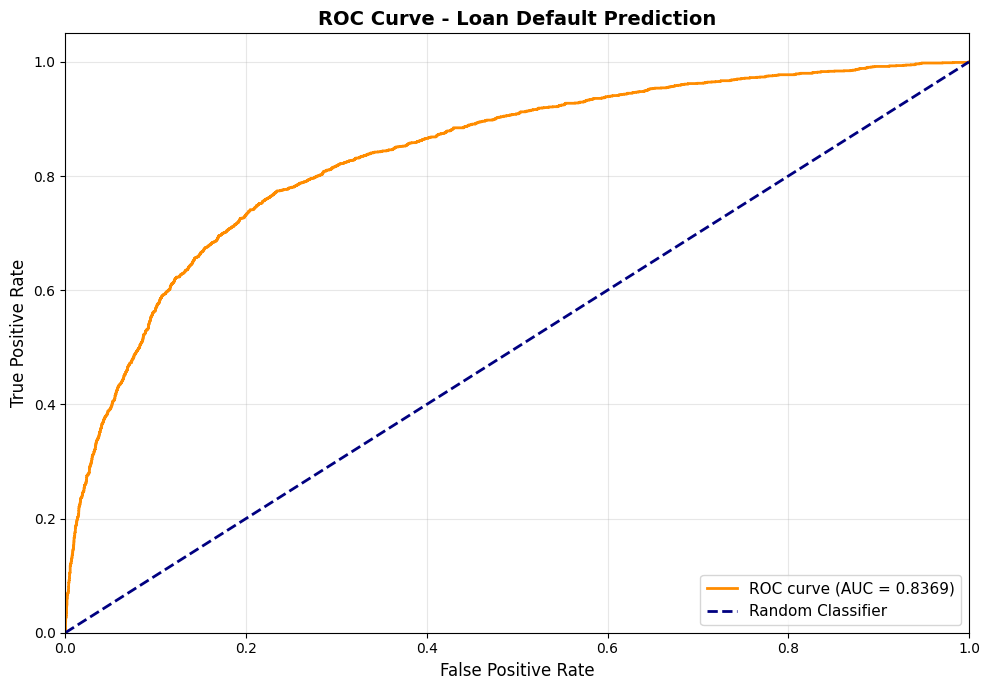

In [83]:
fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_proba)
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Loan Default Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# PART 3: K-Means Clustering
## Customer Segmentation


## Cell 23 — Prepare Data for Clustering


In [84]:
features_cluster = ['person_income', 'loan_amnt', 'loan_int_rate', 
                    'credit_score', 'person_age', 'person_emp_exp']
X_cluster = df_model[features_cluster]


## Cell 24 — Feature Scaling


In [85]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


## Cell 25 — Elbow Method (Find Optimal K)


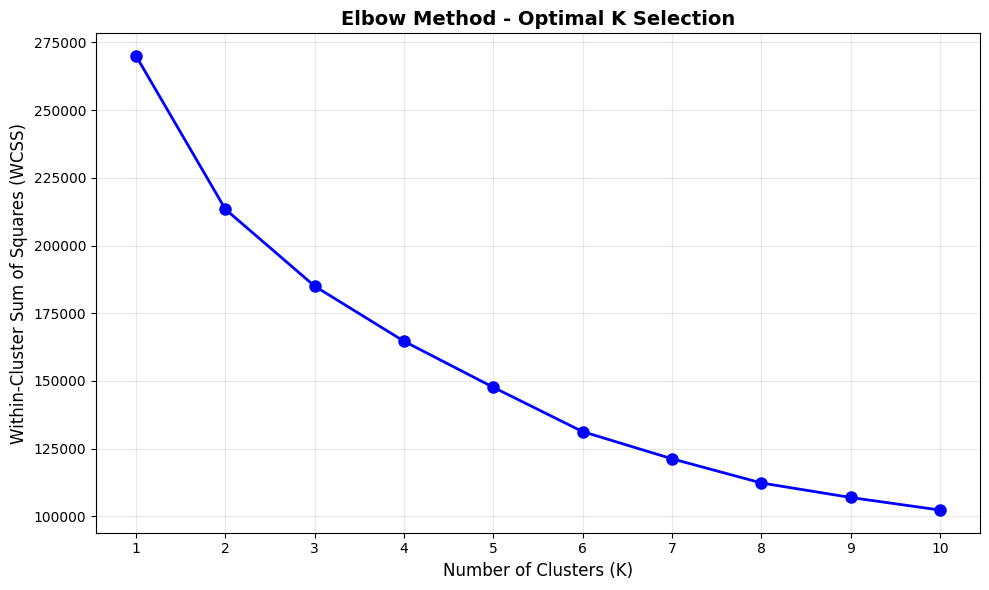

In [86]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    wcss.append(kmeans_temp.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method - Optimal K Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()


## Cell 26 — Train K-Means with Optimal K


In [87]:
BEST_K = 4
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
df_model['Cluster'] = clusters
silhouette_avg = silhouette_score(X_cluster_scaled, clusters)
print(f"Silhouette Score for K={BEST_K}: {silhouette_avg:.4f}")


Silhouette Score for K=4: 0.1955


## Cell 27 — Analyze Cluster Characteristics


In [88]:
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters
for cluster_id in range(BEST_K):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} Characteristics (Size: {len(cluster_data)}) ---")
    print(cluster_data[features_cluster].mean())



--- Cluster 0 Characteristics (Size: 19502) ---
person_income     67702.741206
loan_amnt          6887.210337
loan_int_rate        10.504867
credit_score        658.782484
person_age           25.655164
person_emp_exp        3.342529
dtype: float64

--- Cluster 1 Characteristics (Size: 11087) ---
person_income     69402.848922
loan_amnt          7739.388202
loan_int_rate        10.690617
credit_score        569.934608
person_age           25.418508
person_emp_exp        3.020114
dtype: float64

--- Cluster 2 Characteristics (Size: 7795) ---
person_income     119675.882617
loan_amnt          19453.651315
loan_int_rate         12.794783
credit_score         638.501090
person_age            27.061193
person_emp_exp         4.623861
dtype: float64

--- Cluster 3 Characteristics (Size: 6616) ---
person_income     89431.022521
loan_amnt          8990.312122
loan_int_rate        10.908275
credit_score        653.542473
person_age           38.740024
person_emp_exp       16.437727
dtype: floa

## Cell 28 — Visualize Clusters (2D using PCA)


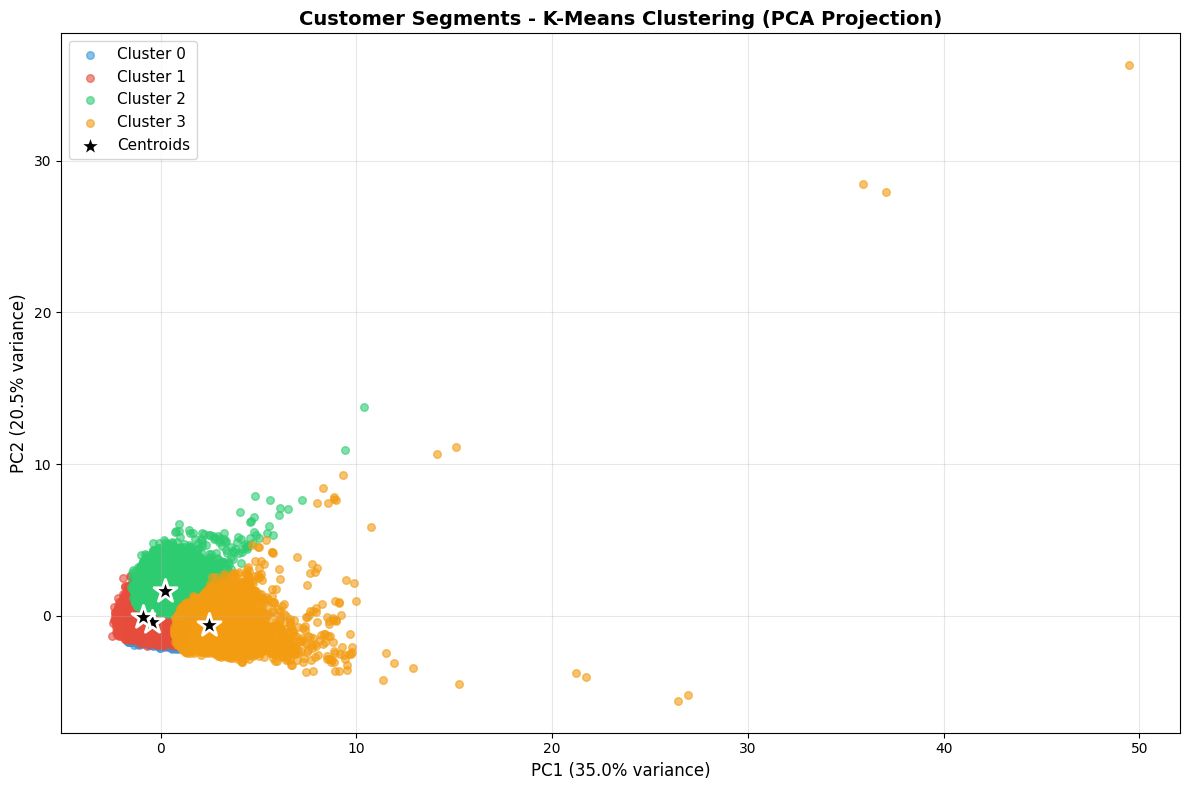

Total Explained Variance (PC1 + PC2): 55.54%


In [89]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
plt.figure(figsize=(12, 8))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for k in range(BEST_K):
    mask = pca_df['Cluster'] == k
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                label=f'Cluster {k}', alpha=0.6, s=30, color=colors[k])
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            s=300, c='black', marker='*', edgecolors='white', linewidth=2,
            label='Centroids', zorder=5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Customer Segments - K-Means Clustering (PCA Projection)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
var_explained = sum(pca.explained_variance_ratio_) * 100
print(f"Total Explained Variance (PC1 + PC2): {var_explained:.2f}%")


## Cell 29 — Visualize Clusters (Feature Pairs)


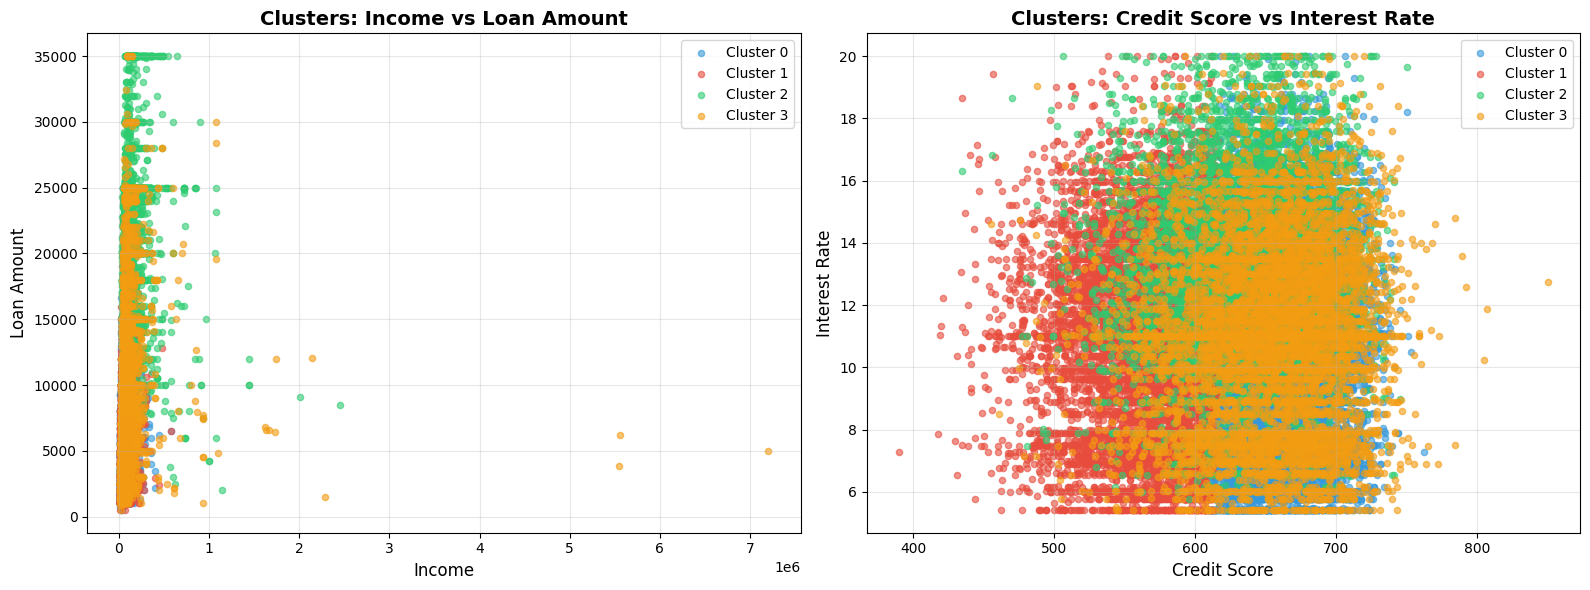

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_viz = df.copy()
df_viz['Cluster'] = clusters
for k in range(BEST_K):
    cluster_data = df_viz[df_viz['Cluster'] == k]
    axes[0].scatter(cluster_data['person_income'], cluster_data['loan_amnt'],
                   label=f'Cluster {k}', alpha=0.6, s=20, color=colors[k])
axes[0].set_xlabel('Income', fontsize=12)
axes[0].set_ylabel('Loan Amount', fontsize=12)
axes[0].set_title('Clusters: Income vs Loan Amount', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for k in range(BEST_K):
    cluster_data = df_viz[df_viz['Cluster'] == k]
    axes[1].scatter(cluster_data['credit_score'], cluster_data['loan_int_rate'],
                   label=f'Cluster {k}', alpha=0.6, s=20, color=colors[k])
axes[1].set_xlabel('Credit Score', fontsize=12)
axes[1].set_ylabel('Interest Rate', fontsize=12)
axes[1].set_title('Clusters: Credit Score vs Interest Rate', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ------------------------------------ END ------------------------------------